In [1]:
import sys
from pathlib import Path

In [2]:
sys.path.append("../")

In [3]:
import torch
import sys
sys.path.append("../../../sun/src")
import os
from glob import glob as glob 
from natsort import natsorted as ns 
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
import torchvision.transforms.functional as TF
from segmentation.SegmentationMap import SegmentationMap as SM
from segmentation.toolbox import scale_im_up, crop


In [4]:
stimuli = glob("/Users/tb/Documents/lab/projects/oberon/ims/fullsize/*.jpg")

In [5]:
images = glob("/Users/tb/Documents/lab/projects/oberon/from_humans/stimuli/*k4.jpg")

In [6]:
images

['/Users/tb/Documents/lab/projects/oberon/from_humans/stimuli/122048_k4.jpg',
 '/Users/tb/Documents/lab/projects/oberon/from_humans/stimuli/249061_k4.jpg',
 '/Users/tb/Documents/lab/projects/oberon/from_humans/stimuli/178054_k4.jpg',
 '/Users/tb/Documents/lab/projects/oberon/from_humans/stimuli/188063_k4.jpg']

# FlexMM with vgg19 basis

In [12]:
image = Image.open(images[3]).convert("RGB")

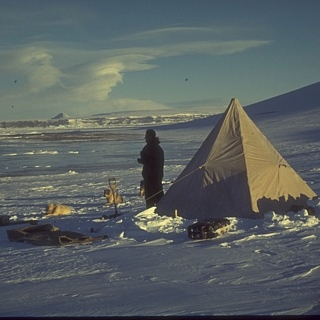

In [13]:
image

In [14]:
def resize_transform(
    mask_image: Image,
    image_size: int = 320,
    patch_size: int = 16,
    tensor=True 
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))

    out = TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))
    if tensor:
        return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))
    else:
        out = out.numpy().transpose(1,2,0)

        return out 

In [15]:
arr = resize_transform(image,tensor=False)

In [16]:
arr = (arr*255).astype(int)

In [40]:
flexmm = SM((0,arr),mode="array")

In [12]:
flexmm.fit_model(
    model="c",
    n_components=np.array([3]),
    layer_stop=5,
    keep=True,
    init=None,
    init_eps=None,
    spatial_smoothing=True,
    deepnet="vgg19",
    layer_normalization=True,
    n_pca=0.95)

/Users/tb/miniconda3/envs/dinov3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tb/miniconda3/envs/dinov3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using vgg19


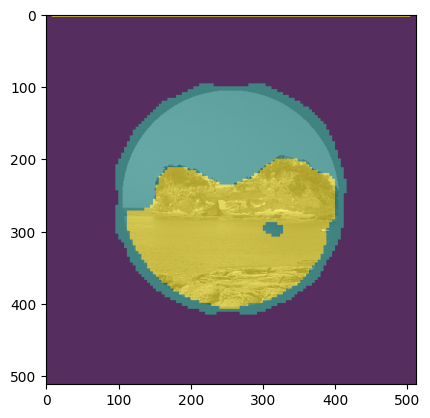

In [13]:
plt.imshow(flexmm.segmap)
plt.imshow(arr,alpha=0.4)

# FlexMM with DINOv3 basis

In [45]:
flexmm.fit_model(
    model="c",
    n_components=np.array([4]),
    layer_stop=3,
    keep=True,
    init=None,
    init_eps=None,
    spatial_smoothing=True,
    deepnet="dinov3",
    layer_normalization=True,
    n_pca=0.95)

Using dinov3


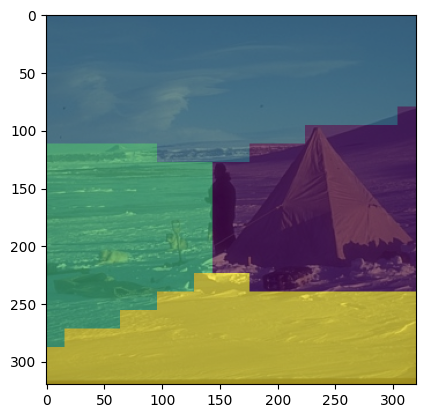

In [46]:
plt.imshow(scale_im_up(flexmm.segmap,320))
plt.imshow(arr,alpha=0.4)

# SAM segmentation

In [17]:
from segmentation.sam_tools import sam_k_segmentation_map

In [18]:
map = sam_k_segmentation_map(
    arr,
    K=20,
    points_per_side=32,
    min_mask_region_area=225
)

In [19]:
np.unique(map)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19], dtype=uint8)

In [20]:
import glasbey
colors = glasbey.create_palette(palette_size = len(np.unique(map)),optimize_palette=True,optimize_palette_search_radius=30)
from matplotlib.colors import ListedColormap
_cmap = ListedColormap(colors)

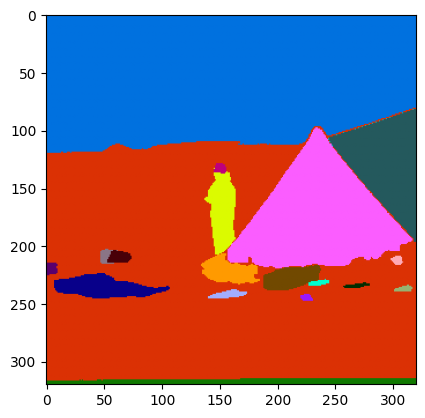

In [21]:
plt.imshow(map,cmap=_cmap)
#plt.imshow(arr,alpha=0.4)

In [17]:
ig = np.unique(map, return_inverse=True)[1].reshape(map.shape)

In [18]:
import numpy as np
from scipy import stats

def bin_label_map_512_to_32(label_map):
    label_map = np.asarray(label_map)
    assert label_map.shape == (512, 512)

    blocks = label_map.reshape(32, 16, 32, 16)
    blocks = blocks.transpose(0, 2, 1, 3)
    blocks = blocks.reshape(32, 32, 256)

    return stats.mode(blocks, axis=-1, keepdims=False).mode

In [19]:
patch_ig = bin_label_map_512_to_32(ig)

In [20]:
patch_ig = np.unique(patch_ig, return_inverse=True)[1].reshape(patch_ig.shape)

In [21]:
flexmm = SM((0,arr),mode="array")

In [22]:
np.unique(patch_ig)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [32]:
flexmm.fit_model(
    model="c",
    n_components=np.array([10]),
    layer_stop=3,
    keep=True,
    init=patch_ig,
    init_eps=None,
    spatial_smoothing=True,
    deepnet="dinov3",
    layer_normalization=True,
    n_pca=0.95)

Using dinov3


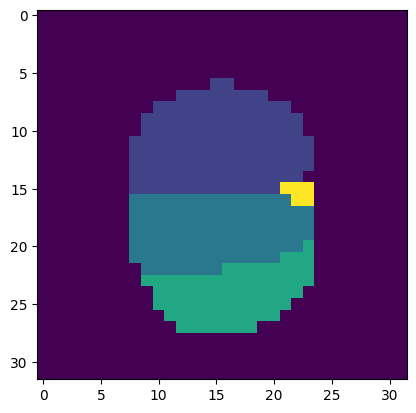

In [33]:
plt.imshow(flexmm.segmap)

In [38]:
np.unique(patch_ig)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

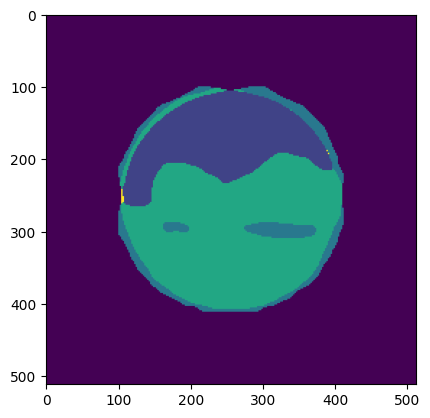

In [22]:
plt.imshow(flexmm.segmap)

# DINOv3 Features

In [60]:
REPO_DIR = "/Users/tb/Documents/lab/projects/saturn/dinov3"

In [61]:
weights_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoidXR2NnlwbjVzc3AyNGVlNGkwOGVpNjd6IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NzkyMzA4NTZ9fX1dfQ__&Signature=DNtJGVA%7E0jxC0zivX3ohslh9IJJbx5Os06qnoq8nBgBCi%7EYxbMF0s5XP44gltOQ-w8W4FpjZ%7ESJIn%7EBJLPNjbiYuGbrPbId3jf-Uzo24rLiiurugXe1iSGuXL2KRpJQrjkUUdVUADFI%7EXZnjtOvMuQ8JpVayrAXTcZjLq8K6qF4iRovUIkFiCcNh-%7E3hNxrrx4i9EVKwnhPdIMOAtxlGPuSdFrIQJXjY7NzQwfvfAbPZ1b7q8WsLjNB6ZTkq1dPZO93BQvrVg0MInAVkhB173x90B3RWZD%7E%7EKgrvOT%7E8f40ttdOkrh1jbk2qYOtR1P5odvp889p4RUwH%7E6A83BOVuQ__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=26796958033329088"


In [62]:
image_resized = resize_transform(image,tensor=True)

In [63]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
image_resized_norm = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

In [64]:
dinov3_vits16 = torch.hub.load(REPO_DIR, 'dinov3_vits16', source='local', weights=weights_url)

In [65]:
dinov3_vits16

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

In [66]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

MODEL_NAME = MODEL_DINOV3_VITS

model = dinov3_vits16

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

with torch.inference_mode():
    with torch.autocast(device_type='cpu', dtype=torch.float32):
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0).cpu(), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)

/var/folders/0f/xg7dbfk947b9_08d5ttfr8480000gn/T/ipykernel_54454/3950338272.py:25: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type='cpu', dtype=torch.float32):


In [67]:
x = x.numpy()

In [69]:
xrs = x.reshape((32,32,384))

In [70]:
from sklearn.decomposition import PCA

In [72]:
model = PCA(n_components=0.95)

In [73]:
res = model.fit_transform(x)

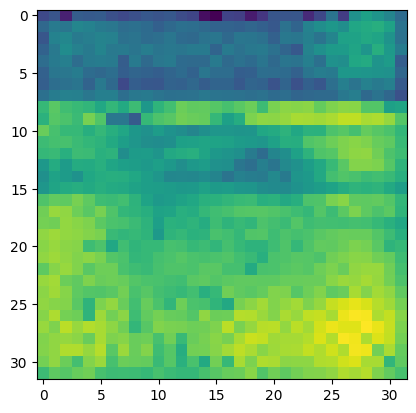

In [78]:
plt.imshow(xrs[:,:,9])